In [ ]:
from google.colab import files
files.upload()

Epoch 1, Loss: 0.001349
Epoch 2, Loss: 0.000722
Epoch 3, Loss: 0.000667
Epoch 4, Loss: 0.000556
Epoch 5, Loss: 0.000521
Epoch 6, Loss: 0.000466
Epoch 7, Loss: 0.000390
Epoch 8, Loss: 0.000329
Epoch 9, Loss: 0.000280
Epoch 10, Loss: 0.000250
Input SNR: 5.00 dB
Output SNR: 0.21 dB


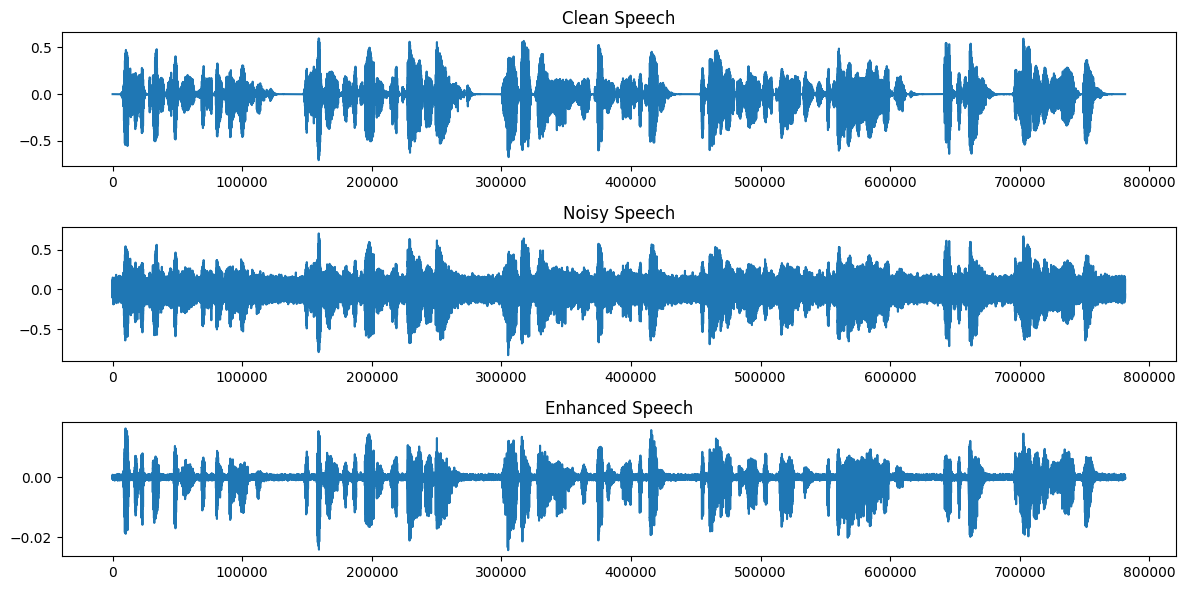

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:8233: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


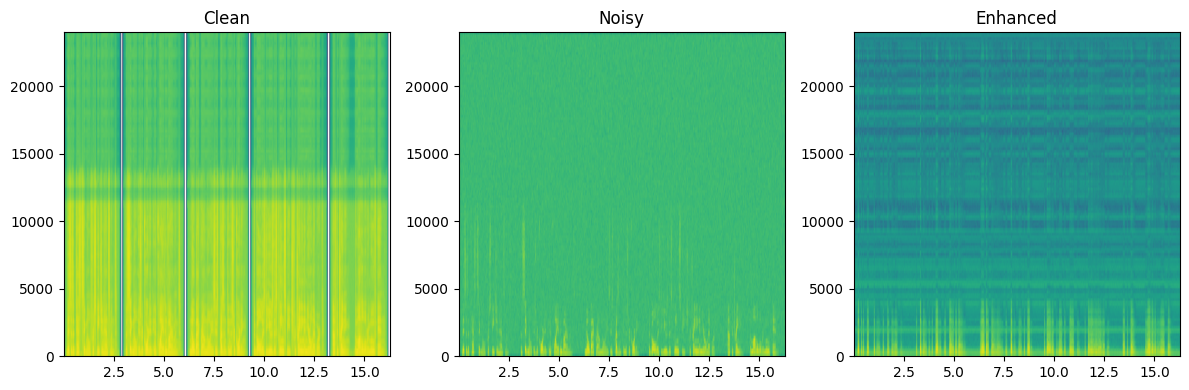

In [2]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import soundfile as sf

# ------------------ LOAD AUDIO ------------------
clean, fs = librosa.load("clean_speech.wav", sr=None)

# Add noise
snr_target = 5
noise = np.random.randn(len(clean))
signal_power = np.mean(clean**2)
noise_power = signal_power / (10**(snr_target/10))
noise = noise * np.sqrt(noise_power / np.mean(noise**2))
noisy = clean + noise

# ------------------ STFT ------------------
n_fft = 256
hop_length = 128

S_clean = librosa.stft(clean, n_fft=n_fft, hop_length=hop_length)
S_noisy = librosa.stft(noisy, n_fft=n_fft, hop_length=hop_length)

X = np.abs(S_noisy)
Y = np.abs(S_clean)

# Normalize
X = X / np.max(X)
Y = Y / np.max(Y)

# Transpose for training
X_train = torch.tensor(X.T, dtype=torch.float32)
Y_train = torch.tensor(Y.T, dtype=torch.float32)

# ------------------ DNN MODEL ------------------
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        return self.model(x)

model = DNN(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------ TRAIN ------------------
epochs = 10
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, Y_train)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

# ------------------ PREDICTION ------------------
with torch.no_grad():
    Y_pred = model(X_train).numpy().T

# Reconstruct signal
S_enhanced = Y_pred * np.exp(1j * np.angle(S_noisy))
enhanced_dnn = librosa.istft(S_enhanced, hop_length=hop_length)

# ------------------ KALMAN FILTER ------------------
N = len(enhanced_dnn)
x_est = np.zeros(N)
P = 1
Q = 0.001
R = 0.01

for n in range(1, N):
    x_pred = x_est[n-1]
    P_pred = P + Q

    K = P_pred / (P_pred + R)

    x_est[n] = x_pred + K * (enhanced_dnn[n] - x_pred)
    P = (1 - K) * P_pred

enhanced_final = x_est

# ------------------ SNR ------------------
def compute_snr(clean, noisy):
    return 10 * np.log10(np.sum(clean**2) / np.sum((clean - noisy)**2))

snr_input = compute_snr(clean, noisy)
snr_output = compute_snr(clean[:len(enhanced_final)], enhanced_final)

print(f"Input SNR: {snr_input:.2f} dB")
print(f"Output SNR: {snr_output:.2f} dB")

# ------------------ SAVE OUTPUT ------------------
sf.write("enhanced_output.wav", enhanced_final, fs)

# ------------------ PLOTS ------------------
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.title("Clean Speech")
plt.plot(clean)
plt.grid()

plt.subplot(3,1,2)
plt.title("Noisy Speech")
plt.plot(noisy)
plt.grid()

plt.subplot(3,1,3)
plt.title("Enhanced Speech")
plt.plot(enhanced_final)
plt.grid()

plt.tight_layout()
plt.show()

# ------------------ SPECTROGRAMS ------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Clean")
plt.specgram(clean, Fs=fs)
plt.grid()

plt.subplot(1,3,2)
plt.title("Noisy")
plt.specgram(noisy, Fs=fs)
plt.grid()

plt.subplot(1,3,3)
plt.title("Enhanced")
plt.specgram(enhanced_final, Fs=fs)
plt.grid()

plt.tight_layout()
plt.show()